In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geodesic_toolbox import *
import torch
from torch import Tensor
from utils import *

In [2]:
bounds = torch.tensor([[-1.0, -1.0], [1.0, 1.0]])

In [3]:
cometric = IdentityCoMetric()
omega = Omega(cometric)
omega = ConstantOmega(cometric, beta_vector=torch.tensor([0.8, 0.0]))
omega = WaveOmega(cometric, frequency=1)
omega = RoundOmega(cometric)
# omega = OutsideOmega(cometric)
randers = RandersMetrics(cometric, omega, beta=0.9)
dual_randers = DualRandersMetrics(randers)

In [4]:
#  Random points in the domain
n = 600
# n = 36
X = torch.rand(n, 2) * 2 - 1  # Uniformly distributed in [-1, 1]^
n = X.shape[0]
X.shape

torch.Size([600, 2])

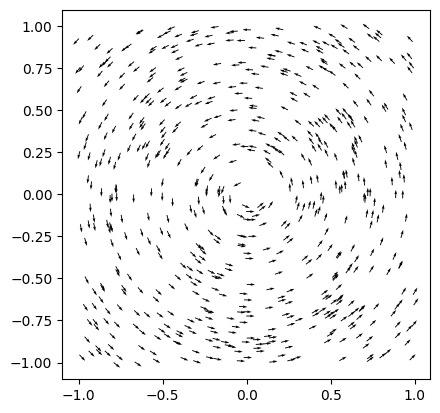

In [5]:
plot_hyperplane(X[::], omega(X).detach()[::], ax=plt.gca(), line_length=0)
plt.gca().set_aspect("equal")

In [6]:
solver_georce = SolverGraphGEORCEFinsler(randers, data=X, n_neighbors=8)

Initialize Graph:   0%|          | 0/10 [00:00<?, ?batch/s]

Initialize Graph: 100%|██████████| 10/10 [00:01<00:00,  5.38batch/s]


Computing predecessors...
Done.


In [31]:
idx_ = torch.randint(0, n, (2,))
x_0 = X[idx_[0]].unsqueeze(0)

In [32]:
# p_0 = -randers.omega(x_0)
p_0 = torch.randn_like(x_0)
p_0 = p_0 / p_0.norm() * 0.5

In [33]:
def hamiltonian(q, p):
    return 1 / 2 * dual_randers(q, p) ** 2


traj_q, traj_p = [x_0.clone().detach()], [p_0.clone().detach()]

dt = 0.001
for _ in range(100):
    q, p = traj_q[-1], traj_p[-1]
    q.requires_grad_(True)
    p.requires_grad_(True)
    H = hamiltonian(q, p)
    dH_dq = torch.autograd.grad(H, q, create_graph=True)[0]
    dH_dp = torch.autograd.grad(H, p, create_graph=True)[0]
    q_next = q + dH_dp * dt
    p_next = p - dH_dq * dt
    traj_q.append(q_next.clone().detach())
    traj_p.append(p_next.clone().detach())
traj_q = torch.stack(traj_q).squeeze().detach()
traj_p = torch.stack(traj_p).squeeze().detach()

In [34]:
x_1 = traj_q[-1].unsqueeze(0)
true_traj = solver_georce.get_trajectories(x_0, x_1)[0].detach()

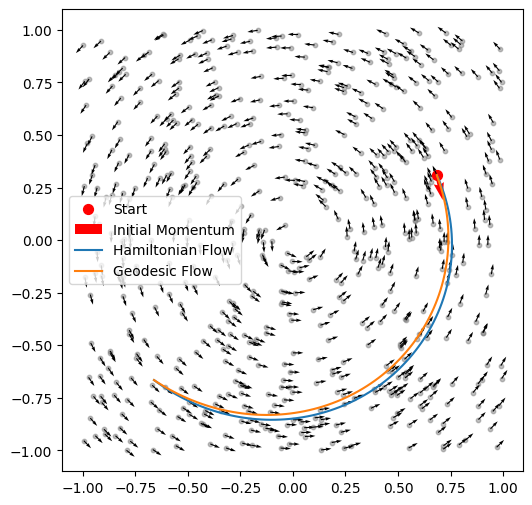

In [35]:
traj_q.shape
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.5, color="gray")
ax.scatter(x_0[:, 0], x_0[:, 1], color="red", s=50, label="Start")
plot_hyperplane(X[::], omega(X).detach()[::], ax=ax, line_length=0)
ax.quiver(x_0[:, 0], x_0[:, 1], p_0[:, 0], p_0[:, 1], color="red", label="Initial Momentum")
ax.plot(traj_q[:, 0], traj_q[:, 1], label="Hamiltonian Flow")
ax.plot(true_traj[:, 0], true_traj[:, 1], label="Geodesic Flow")
ax.legend()
ax.set_aspect("equal")
plt.show()